In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle

import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D



In [9]:
import warnings
warnings.filterwarnings("default")

### Simple model

In [10]:
with open("../results/fungus_class/results_fungal_simplemodel.pkl", "rb") as f:
    results_fungus_class_simple = pickle.load(f)

print(type(results_fungus_class_simple))   # should be dict

<class 'dict'>


In [11]:
results_fungus_class_simple

{('overhead',
  'all',
  '2024-12-21'):              model mean_accuracy std_accuracy mean_balanced_accuracy  \
 logistic  logistic           1.0          0.0                    1.0   
 lda            lda           1.0          0.0                    1.0   
 lasso        lasso           1.0          0.0                    1.0   
 
          std_balanced_accuracy mean_f1_macro std_f1_macro mean_auc_macro_ovr  \
 logistic                   0.0           1.0          0.0                1.0   
 lda                        0.0           1.0          0.0                1.0   
 lasso                      0.0           1.0          0.0                1.0   
 
          std_auc_macro_ovr  
 logistic               0.0  
 lda                    0.0  
 lasso                  0.0  ,
 ('overhead',
  'all',
  '2024-12-22'):              model mean_accuracy std_accuracy mean_balanced_accuracy  \
 logistic  logistic           1.0          0.0                    1.0   
 lda            lda           1.0  

In [12]:
rows = []
for (view, mask_type, date), v in results_fungus_class_simple.items():
    # v is a DataFrame; index = model name, columns = metrics
    df_tmp = v.copy()
    df_tmp = df_tmp.reset_index()
    df_tmp["view"] = view
    df_tmp["mask_type"] = mask_type
    df_tmp["date"] = date
    rows.append(df_tmp)

df_simple = pd.concat(rows, ignore_index=True)

keep = ["view", "mask_type", "date", "model",
        "mean_accuracy", "std_accuracy",
        "mean_auc_macro_ovr", "std_auc_macro_ovr"]
df_simple = df_simple[[c for c in keep if c in df_simple.columns]]
df_simple


,view,mask_type,date,model,mean_accuracy,std_accuracy,mean_auc_macro_ovr,std_auc_macro_ovr
0,overhead,all,2024-12-21,logistic,1.0,0.0,1.0,0.0
1,overhead,all,2024-12-21,lda,1.0,0.0,1.0,0.0
2,overhead,all,2024-12-21,lasso,1.0,0.0,1.0,0.0
3,overhead,all,2024-12-22,logistic,1.0,0.0,1.0,0.0
4,overhead,all,2024-12-22,lda,1.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...
325,raw,plug,2024-12-30,lda,1.0,0.0,1.0,0.0
326,raw,plug,2024-12-30,lasso,1.0,0.0,1.0,0.0
327,raw,plug,2024-12-31,logistic,1.0,0.0,1.0,0.0
328,raw,plug,2024-12-31,lda,1.0,0.0,1.0,0.0


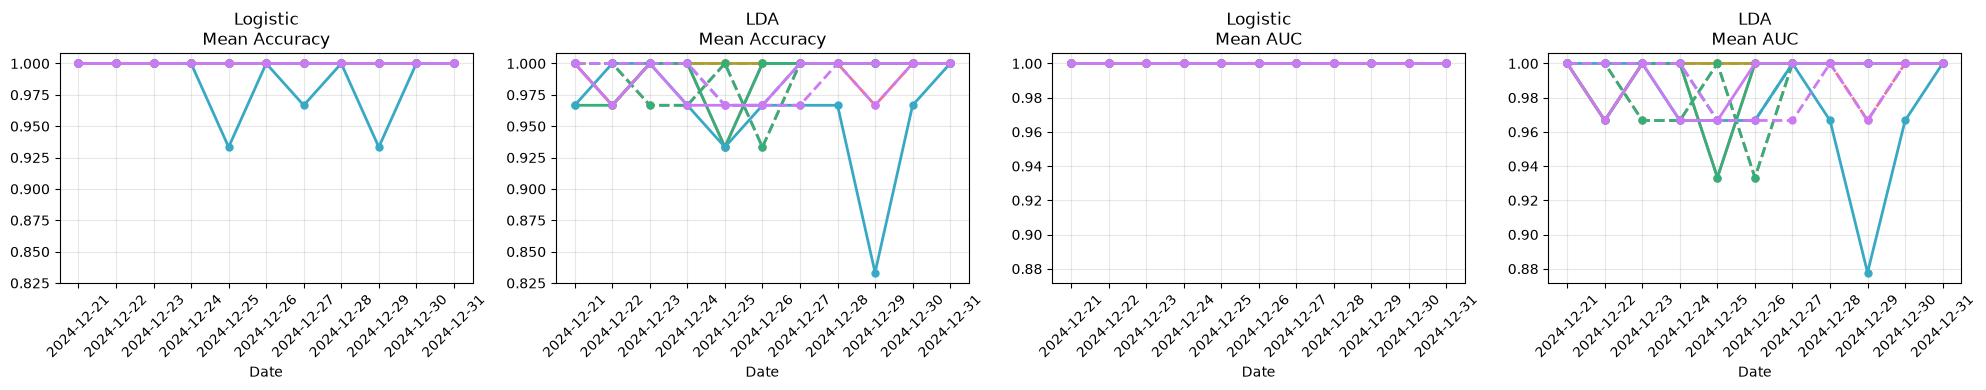

In [13]:
mask_order = ["all", "plug", "all_plug", "new_growth", "old_growth"]
mask_palette = dict(zip(mask_order, sns.color_palette("husl", len(mask_order))))

view_order = ["raw", "overhead"]
view_linestyles = {"raw": "-", "overhead": "--"}

model_order = ["logistic", "lda",
               #"lasso"
               ]
model_label_map_simple = {"logistic": "Logistic", "lda": "LDA", 
                          #"lasso": "LASSO"
                          }
metric_label_map = {"mean_auc_macro_ovr": "Mean AUC", "mean_accuracy": "Mean Accuracy"}

metrics = df_simple.columns[df_simple.columns.str.startswith("mean_")] 

n_rows = 1
n_cols = len(metrics) * len(model_order)

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(5*n_cols, 4),
    sharex=True
)

if n_cols == 1:
    axes = [axes]

for i, metric in enumerate(metrics):
    y_min = df_simple[metric].min()
    y_max = df_simple[metric].max()

    margin = (y_max - y_min) * 0.05
    y_min -= margin
    y_max += margin

    for j, model_s in enumerate(model_order):

        col_idx = i * len(model_order) + j
        ax = axes[col_idx]

        subset = df_simple[df_simple["model"] == model_s]

        for mask_type in mask_order:
            mask_subset = subset[subset["mask_type"] == mask_type]

            for view in view_order:
                view_subset = mask_subset[mask_subset["view"] == view]

                if not view_subset.empty:
                    view_subset = view_subset.sort_values("date")

                    ax.plot(
                        view_subset["date"],
                        view_subset[metric],
                        marker="o",
                        color=mask_palette[mask_type],
                        linestyle=view_linestyles[view],
                        linewidth=2,
                        markersize=5
                    )

        ax.set_ylim(y_min, y_max)

        ax.set_title(
            f"{model_label_map_simple.get(model_s, model_s)}\n"
            f"{metric_label_map.get(metric, metric)}"
        )

        ax.set_xlabel("Date")
        ax.tick_params(axis='x', rotation=45)
        ax.grid(True, alpha=0.3)
    
plt.tight_layout()
#plt.savefig("../results/fungus_class/classification_analysis_fungus.pdf", format="pdf", dpi=300, bbox_inches="tight")
plt.show()


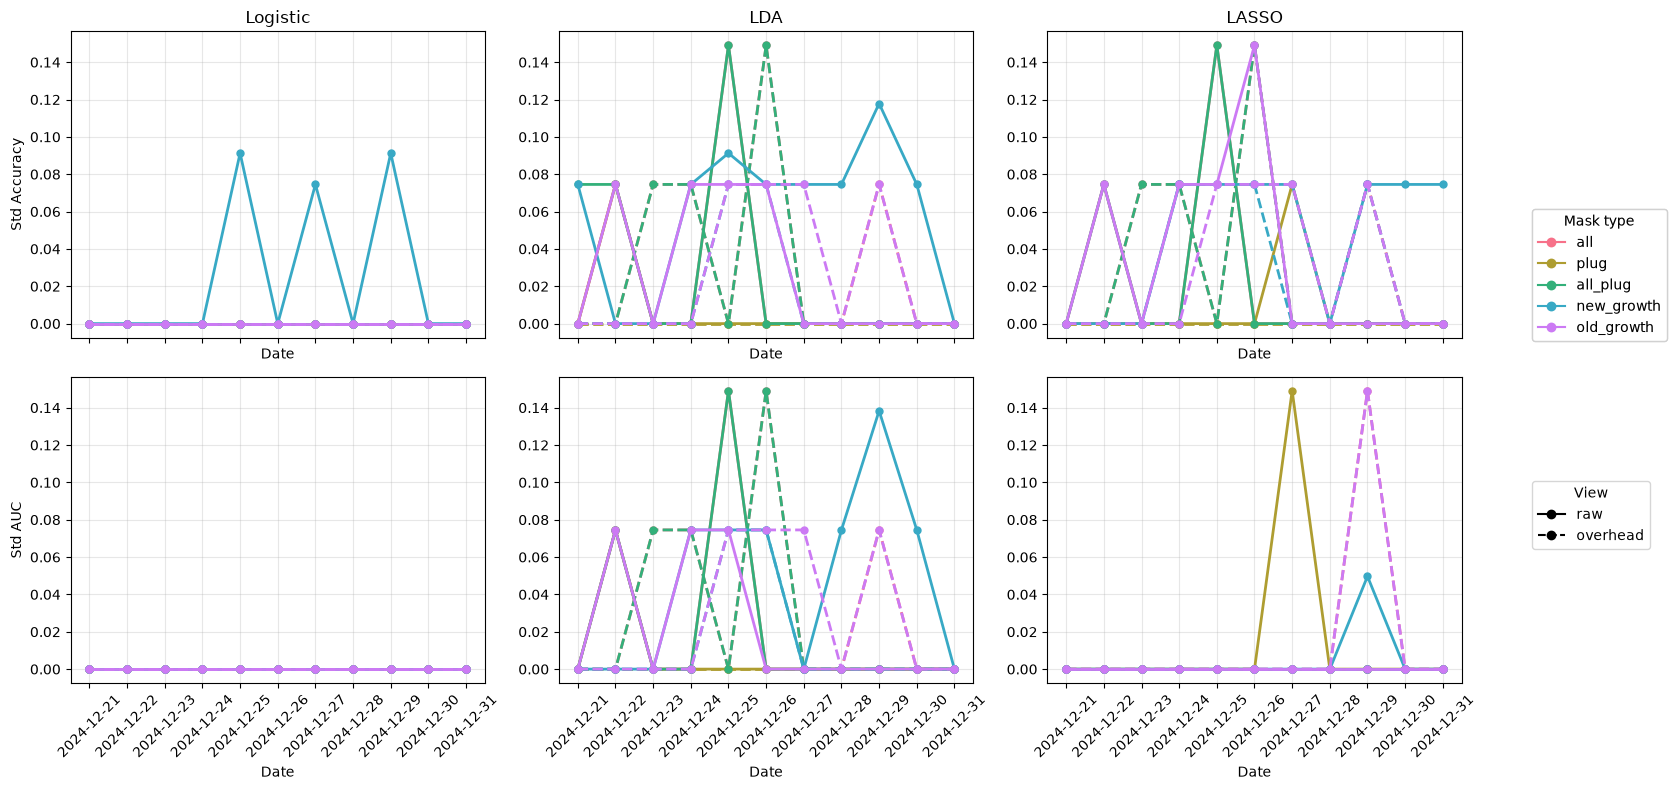

In [14]:
mask_order = ["all", "plug", "all_plug", "new_growth", "old_growth"]
mask_palette = dict(zip(mask_order, sns.color_palette("husl", len(mask_order))))

view_order = ["raw", "overhead"]
view_linestyles = {"raw": "-", "overhead": "--"}

model_order = ["logistic", "lda", "lasso"]
model_label_map_simple = {"logistic": "Logistic", "lda": "LDA", "lasso": "LASSO"}
metric_label_map = {"std_auc_macro_ovr": "Std AUC", "std_accuracy": "Std Accuracy"}

metrics = df_simple.columns[df_simple.columns.str.startswith("std_")] 

n_rows = len(metrics)
n_cols = len(model_order)

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(5*n_cols, 4*n_rows),
    sharex=True
)

if n_rows == 1:
    axes = [axes]
if n_cols == 1:
    axes = [[ax] for ax in axes]

for i, metric in enumerate(metrics):
    y_min = df_simple[metric].min()
    y_max = df_simple[metric].max()

    margin = (y_max - y_min) * 0.05
    y_min -= margin
    y_max += margin
    for j, model_s in enumerate(model_order):

        ax = axes[i][j]

        subset = df_simple[df_simple["model"] == model_s]
        for mask_type in mask_order:
            mask_subset = subset[subset["mask_type"] == mask_type]

            for view in view_order:
                view_subset = mask_subset[mask_subset["view"] == view]

                if not view_subset.empty:
                    view_subset = view_subset.sort_values("date")

                    ax.plot(
                        view_subset["date"],
                        view_subset[metric],
                        marker="o",
                        color=mask_palette[mask_type],
                        linestyle=view_linestyles[view],
                        linewidth=2,
                        markersize=5
                    )
        ax.set_ylim(y_min, y_max)
        if i == 0:
            ax.set_title(model_label_map_simple.get(model_s, model_s))

        if j == 0:
            ax.set_ylabel(metric_label_map.get(metric, metric.replace("_", " ").title()))
        else:
            ax.set_ylabel("")

        ax.set_xlabel("Date")
        ax.tick_params(axis='x', rotation=45)
        ax.grid(True, alpha=0.3)

mask_legend = [
    Line2D([0], [0],
           color=mask_palette[m],
           linestyle='-',
           marker='o',
           label=m)
    for m in mask_order
]

view_legend = [
    Line2D([0], [0],
           color='black',
           linestyle=view_linestyles[v],
           marker='o',
           label=v)
    for v in view_order
]

legend1 = fig.legend(
    handles=mask_legend,
    loc="center left",
    bbox_to_anchor=(1.02, 0.65),
    title="Mask type"
)

legend2 = fig.legend(
    handles=view_legend,
    loc="center left",
    bbox_to_anchor=(1.02, 0.35),
    title="View"
)

fig.add_artist(legend1)

plt.tight_layout()
# plt.savefig("../results/plot/classification_analysis_fungus.pdf", format="pdf", dpi=300, bbox_inches="tight")

plt.show()


### Simple model - color

In [15]:
results_fungus_class_color_simple = pd.read_csv("../results/fungus_class/results_fungal_color_simplemodel.csv")

In [16]:
df_simple_color = results_fungus_class_color_simple

In [17]:
df_simple_color.head()

,trait_set,model,mean_accuracy,std_accuracy,mean_balanced_accuracy,std_balanced_accuracy,mean_f1_macro,std_f1_macro,mean_auc_macro_ovr,std_auc_macro_ovr,view,mask_type,date
0,RGB,logistic,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,overhead,all,2024-12-21
1,RGB,lda,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,overhead,all,2024-12-21
2,RGB,lasso,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,overhead,all,2024-12-21
3,HSV,logistic,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,overhead,all,2024-12-21
4,HSV,lda,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,overhead,all,2024-12-21


In [18]:
metrics = df_simple_color.columns[df_simple_color.columns.str.startswith("mean_")]
color_types = ['Ncolor', 'Grey', 'RGB', 'HSV', 'LAB']

model_order = ["logistic", "lda",
               #"lasso"
               ]
model_label_map_simple = {"logistic": "Logistic", "lda": "LDA", 
                          #"lasso": "LASSO"
                          }
n_rows = len(model_order)
n_cols = len(color_types)

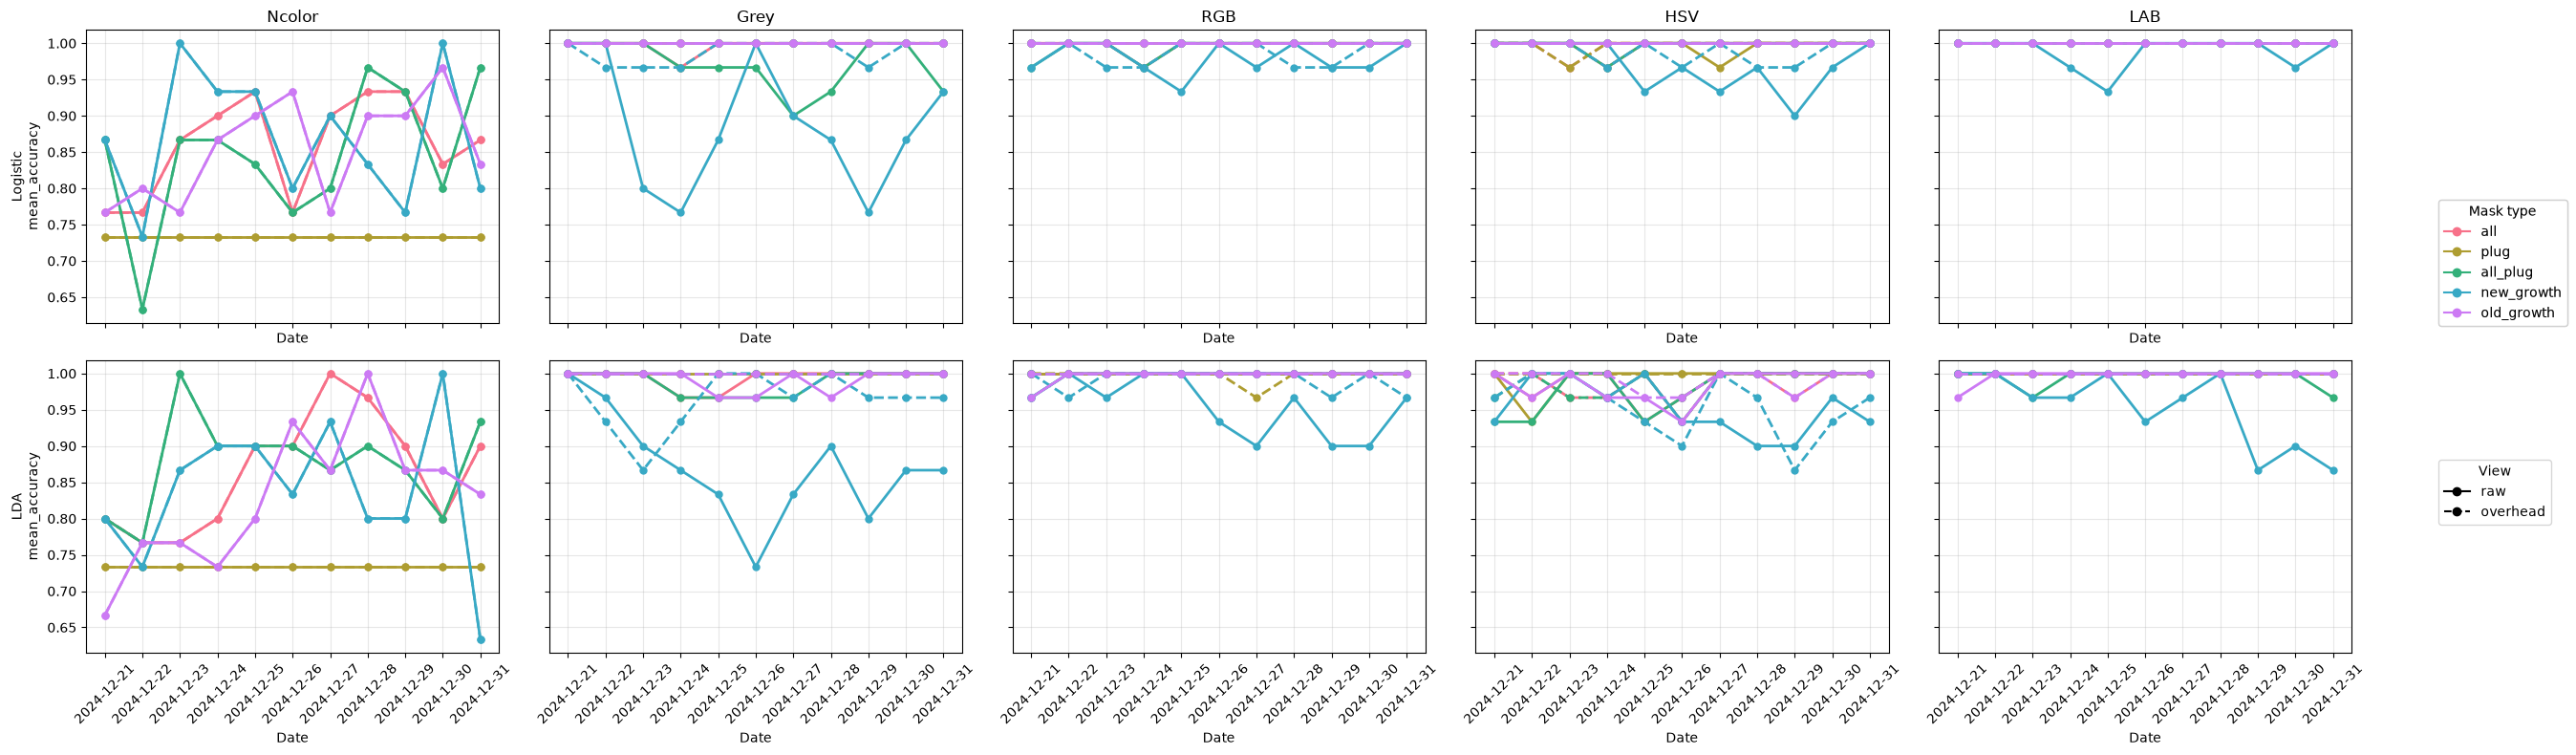

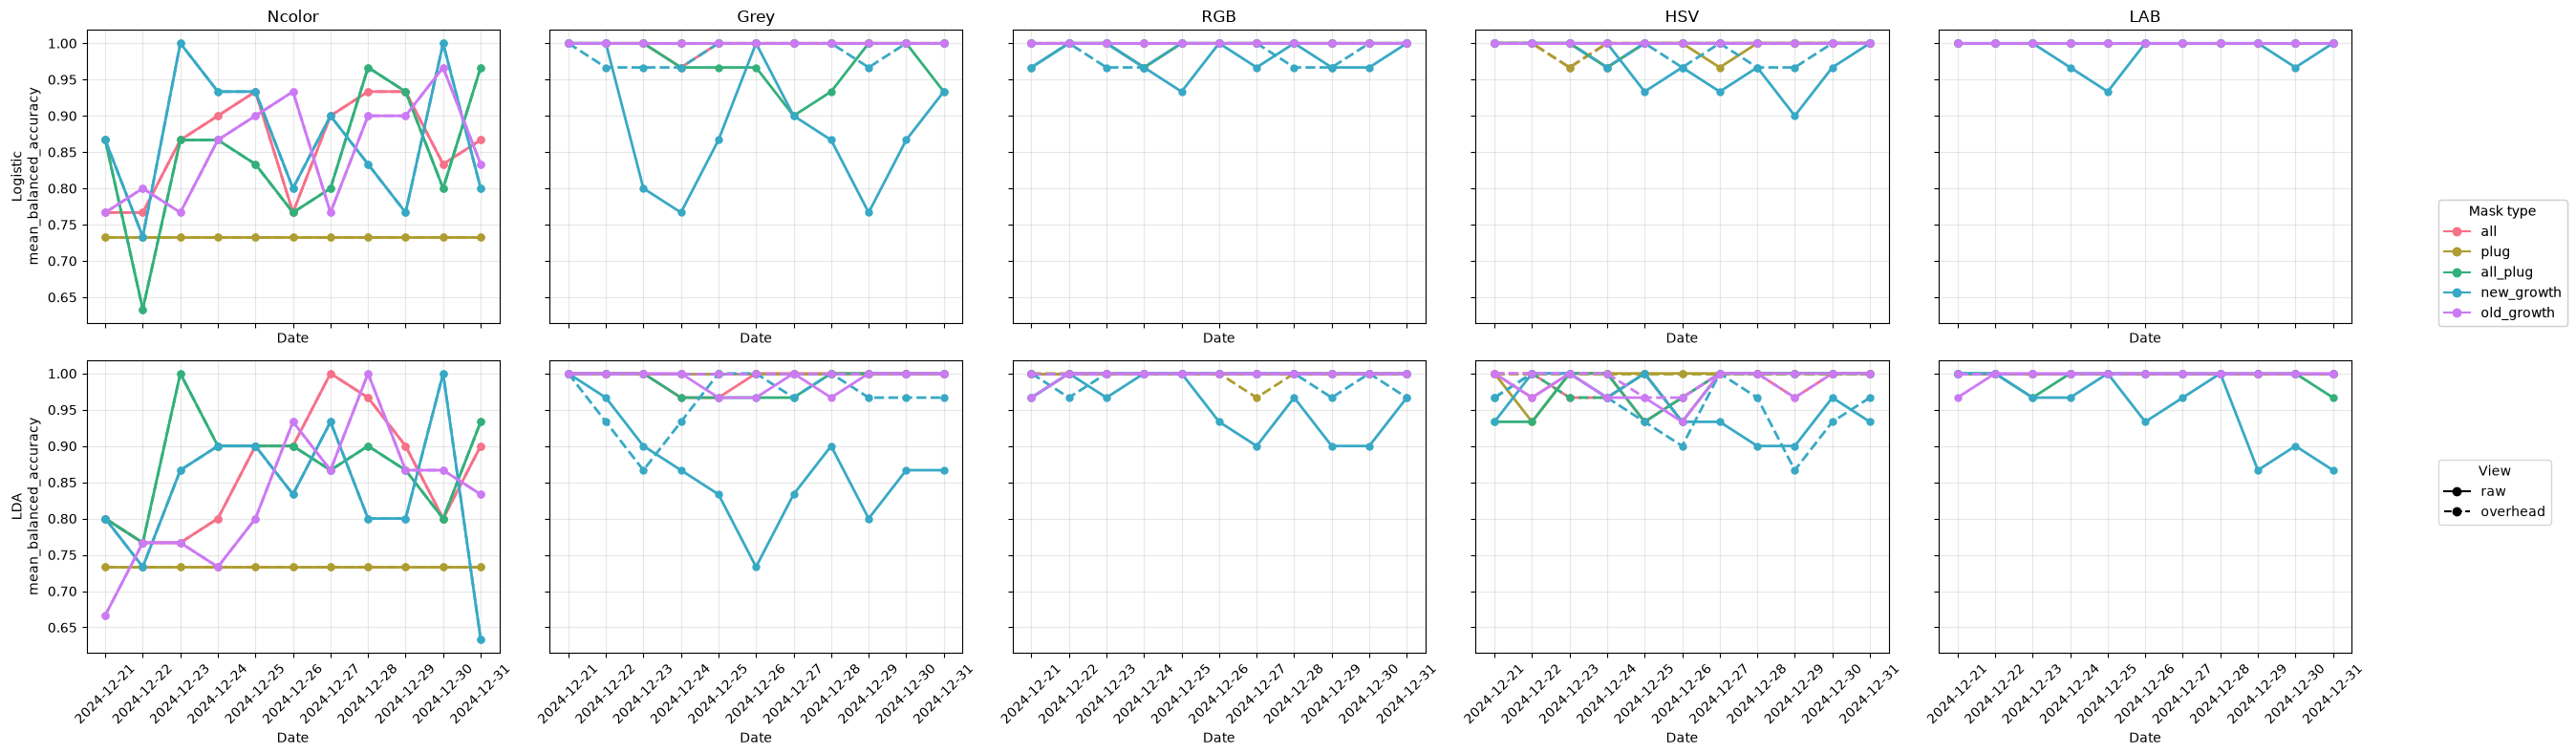

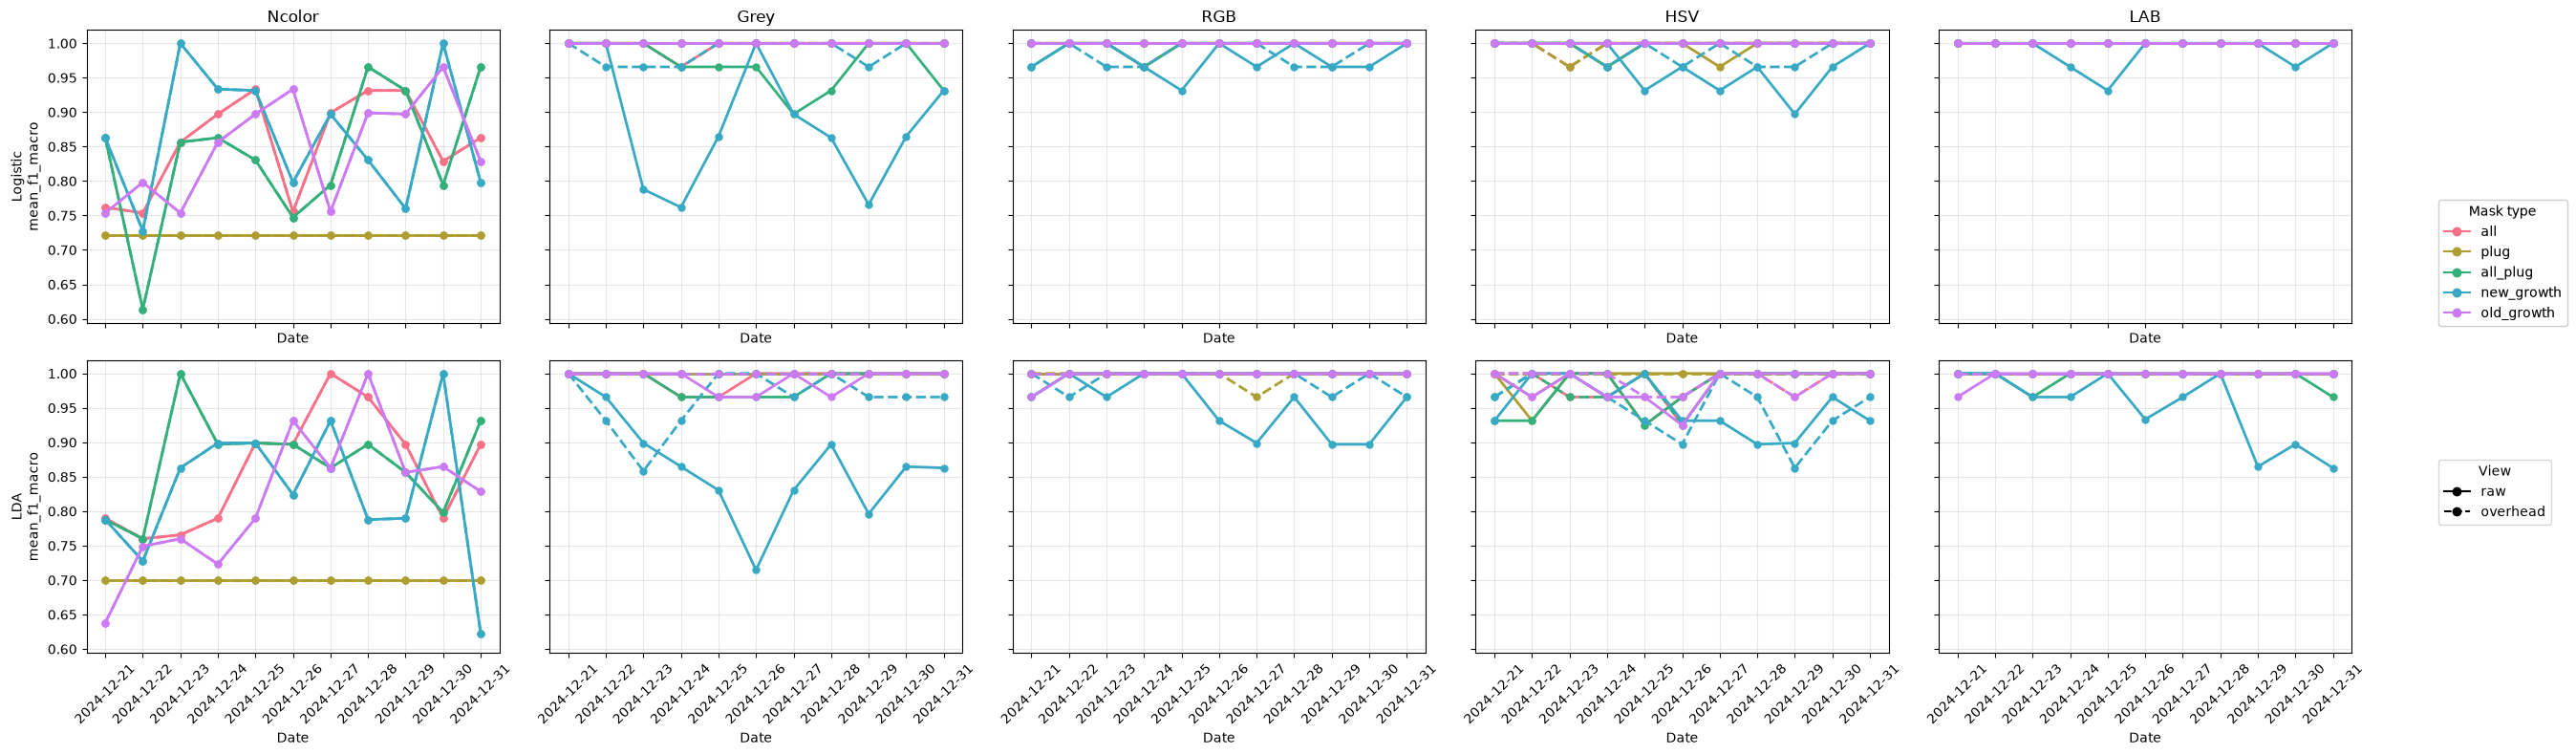

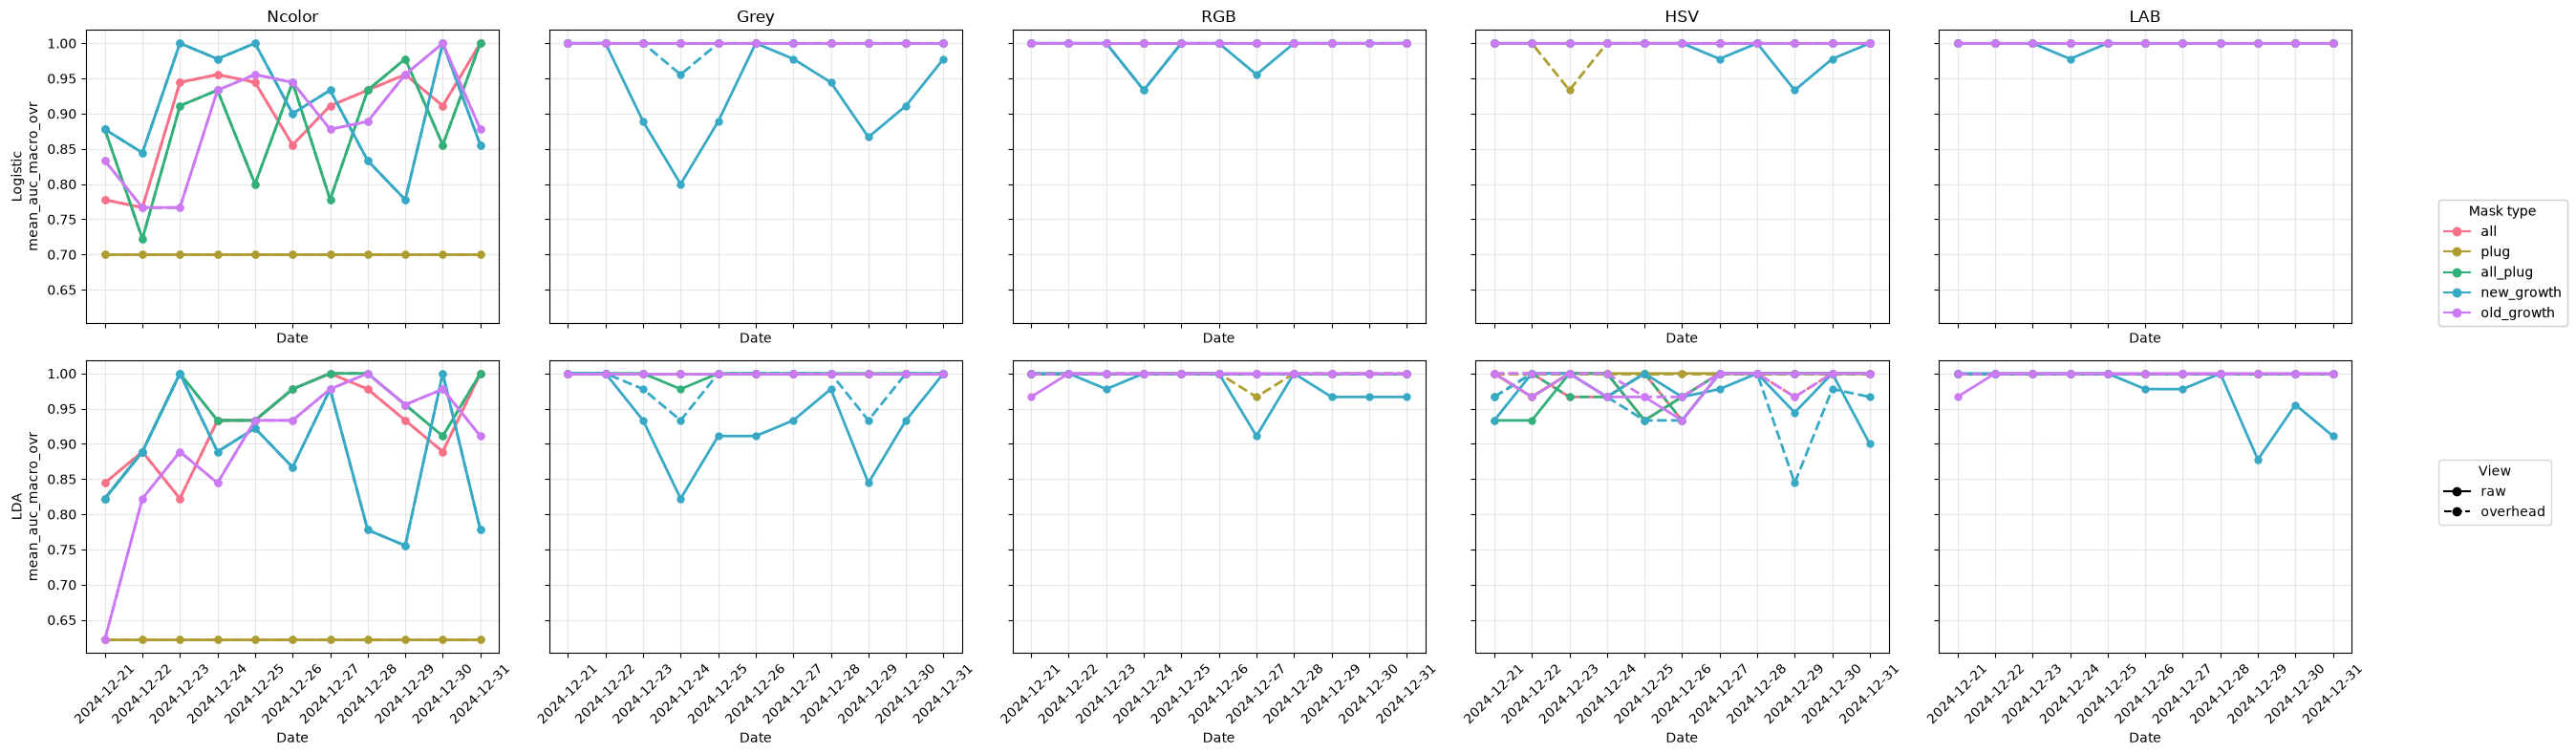

In [19]:
for trait in metrics:
    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(5*n_cols, 4*n_rows),
        sharex=True,
        sharey=True
    )

    if n_rows == 1:
        axes = [axes]
    if n_cols == 1:
        axes = [[ax] for ax in axes]

    legend_handles = {}

    for i, model in enumerate(model_order):
        for j, color_type in enumerate(color_types):

            ax = axes[i][j]

            subset = df_simple_color[
                (df_simple_color["model"] == model) &
                (df_simple_color["trait_set"] == color_type)
            ]

            for mask_type in mask_order:
                mask_subset = subset[subset["mask_type"] == mask_type]

                for view in view_order:
                    view_subset = mask_subset[mask_subset["view"] == view]

                    if not view_subset.empty:
                        view_subset = view_subset.sort_values("date")

                        line, = ax.plot(
                            view_subset["date"],
                            view_subset[trait],
                            marker="o",
                            color=mask_palette[mask_type],
                            linestyle=view_linestyles[view],
                            linewidth=2,
                            markersize=5,
                            label=f"{view}-{mask_type}"
                        )

                        key = f"{view}-{mask_type}"
                        if key not in legend_handles:
                            legend_handles[key] = line

            # Column titles on top row
            if i == 0:
                ax.set_title(color_type)

            # Row labels on left column
            if j == 0:
                ax.set_ylabel(f"{model_label_map_simple.get(model, model)}\n{trait}")
            else:
                ax.set_ylabel("")

            ax.set_xlabel("Date")
            ax.tick_params(axis='x', rotation=45)
            ax.grid(True, alpha=0.3)

    # ---- Mask legend (color only) ----
    mask_legend = [
        Line2D([0], [0],
            color=mask_palette[m],
            linestyle='-',
            marker='o',
            label=m)
        for m in mask_order
    ]

    # ---- View legend (linestyle only) ----
    view_legend = [
        Line2D([0], [0],
            color='black',
            linestyle=view_linestyles[v],
            marker='o',
            label=v)
        for v in view_order
    ]

    legend1 = fig.legend(
        handles=mask_legend,
        loc="center left",
        bbox_to_anchor=(1.02, 0.65),
        title="Mask type"
    )

    legend2 = fig.legend(
        handles=view_legend,
        loc="center left",
        bbox_to_anchor=(1.02, 0.35),
        title="View"
    )

    fig.add_artist(legend1)

    plt.tight_layout()
    #plt.savefig(f"../results/fungus_class/classification_analysis_fungus_{trait}.pdf", format="pdf", dpi=300, bbox_inches="tight")
    plt.show()


In [20]:
print("model_order =", model_order)
print("df models =", df_simple_color["model"].unique())

model_order = ['logistic', 'lda']
df models = ['logistic' 'lda' 'lasso']


We used nested cross-validation to evaluate classification performance.

In the outer loop, data were split into five folds by holding out one replicate from each strain × nitrogen combination (6 samples total), yielding balanced test sets.

The remaining 24 samples were used for model training. Hyperparameters were tuned within the training set using an inner cross-validation that preserved the same biological stratification.

Final models were trained on all 24 training samples using optimal hyperparameters and evaluated on the held-out test samples.
Performance metrics were averaged across outer folds. (accuracy, confusion matrixs)


we use 3 Linear models and 1 tree models for classification



### Analysis of Fungus classification
All models (Elastic Net, LDA, PLS-DA, RF) giving ~1.0 accuracy is expected because:
1. The classes are visually separable

In [21]:
with open("../results/fungus_class/results_fungal_update.pkl", "rb") as f:
    results_fungus_class = pickle.load(f)

print(type(results_fungus_class))   # should be dict

<class 'dict'>


In [22]:
rows = []
for (view, mask_type, date), v in results_fungus_class.items():
    s = v[2]["mean_balanced_accuracy"]   # Series: index=model, values=score

    df_tmp = s.rename("mean_balanced_accuracy").reset_index()
    df_tmp.columns = ["model", "mean_balanced_accuracy"]

    df_tmp["view"] = view
    df_tmp["mask_type"] = mask_type
    df_tmp["date"] = date

    rows.append(df_tmp)

df_scores_fungus_class = pd.concat(rows, ignore_index=True)

# optional: reorder columns
df_scores_fungus_class = df_scores_fungus_class[["view", "mask_type", "date", "model", "mean_balanced_accuracy"]]

In [23]:
df_scores_fungus_class['mean_balanced_accuracy'].describe()

count    550.000000
mean       0.994242
std        0.015095
min        0.900000
25%        1.000000
50%        1.000000
75%        1.000000
max        1.000000
Name: mean_balanced_accuracy, dtype: float64

In [24]:
df_scores_fungus_class.head()

,view,mask_type,date,model,mean_balanced_accuracy
0,overhead,all,2024-12-21,ElasticNet_MultinomialLR,1.0
1,overhead,all,2024-12-21,Lasso_MultinomialLR,1.0
2,overhead,all,2024-12-21,ShrinkageLDA,1.0
3,overhead,all,2024-12-21,PLSDA_PLSScores_plus_LR,1.0
4,overhead,all,2024-12-21,RandomForest,1.0


In [25]:
df_scores_fungus_class['model'].unique()

array(['ElasticNet_MultinomialLR', 'Lasso_MultinomialLR', 'ShrinkageLDA',
       'PLSDA_PLSScores_plus_LR', 'RandomForest'], dtype=object)

In [26]:
model_label_map = {
    "ElasticNet_MultinomialLR": "ElasticNet",
    "Lasso_MultinomialLR": "Lasso",
    "ShrinkageLDA": "LDA (shrinkage)",
    "RandomForest": "Random Forest",
    "PLSDA_PLSScores_plus_LR": "PLS-DA + LR",
}

df_scores_fungus_class["model_label"] = (
    df_scores_fungus_class["model"]
    .map(model_label_map)
)

In [27]:
mask_order = ["all", "plug", "all_plug", "new_growth", "old_growth"]
view_order = ["raw", "overhead"]
model_order = sorted(df_scores_fungus_class["model_label"].unique())

<Figure size 900x500 with 0 Axes>

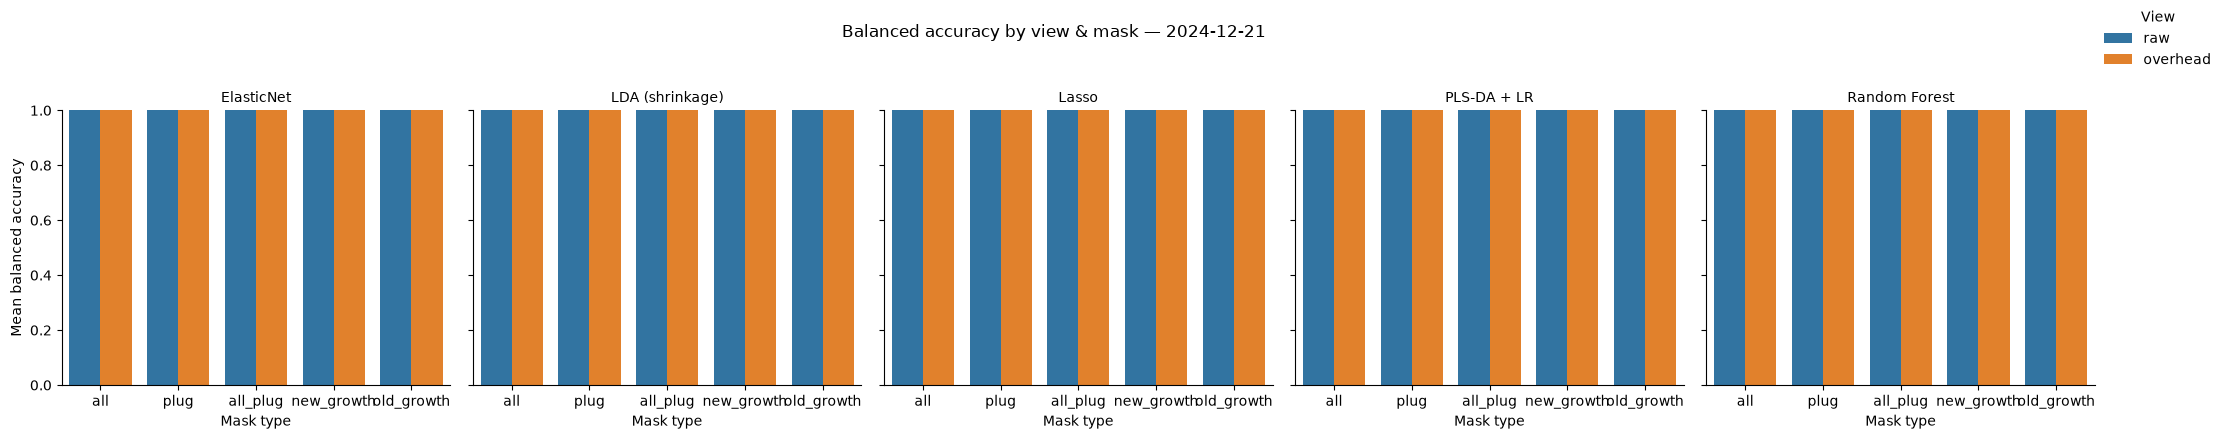

<Figure size 900x500 with 0 Axes>

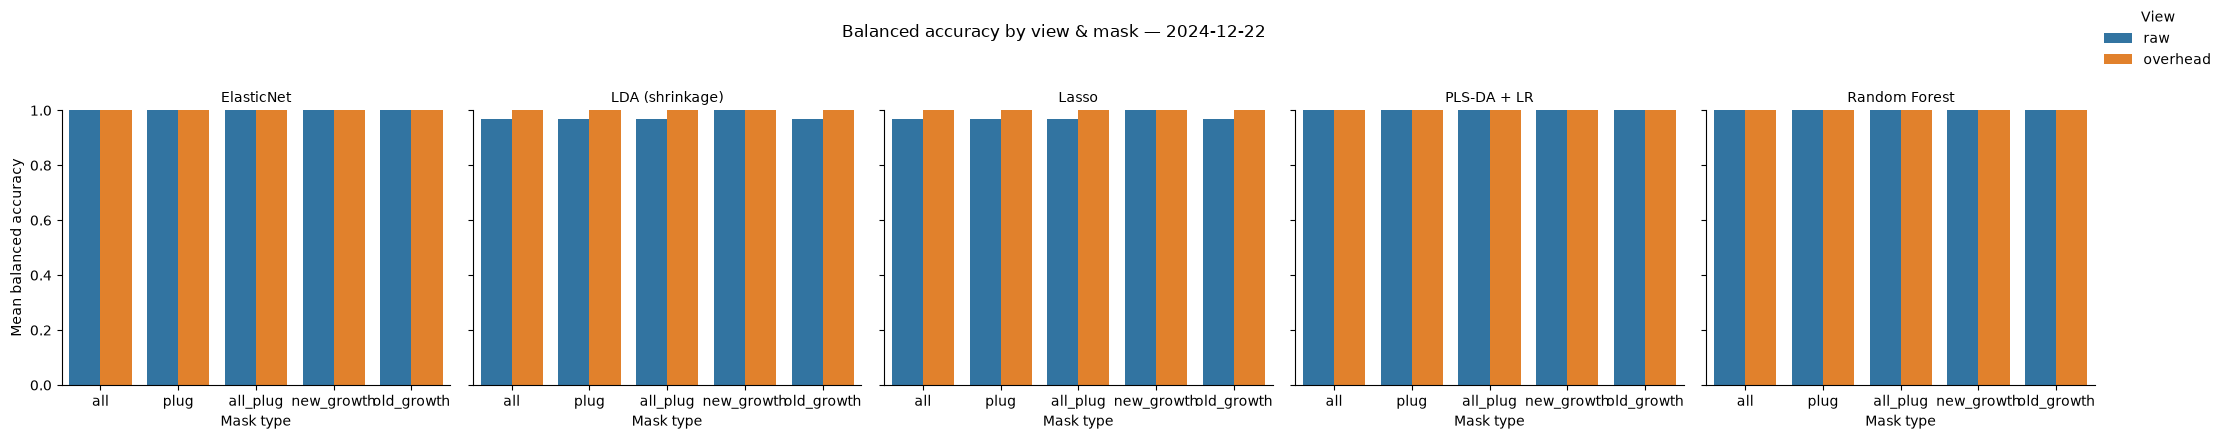

<Figure size 900x500 with 0 Axes>

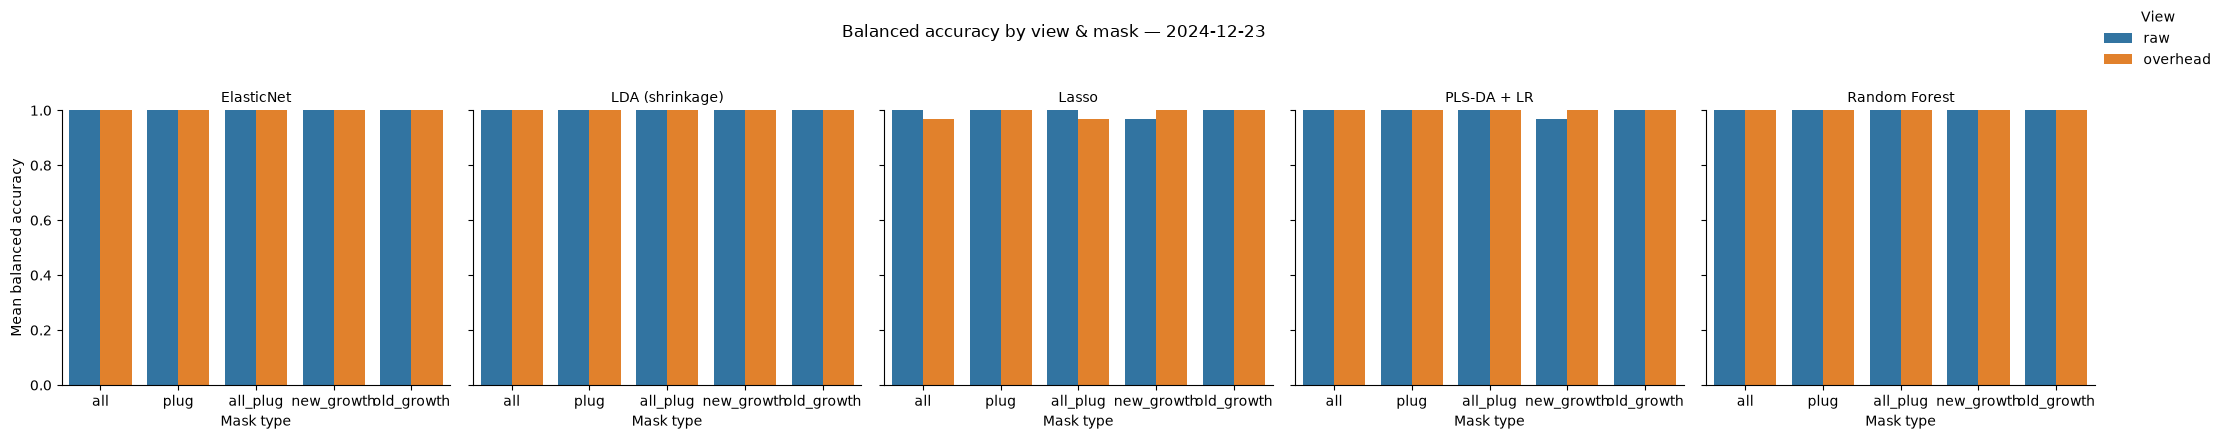

<Figure size 900x500 with 0 Axes>

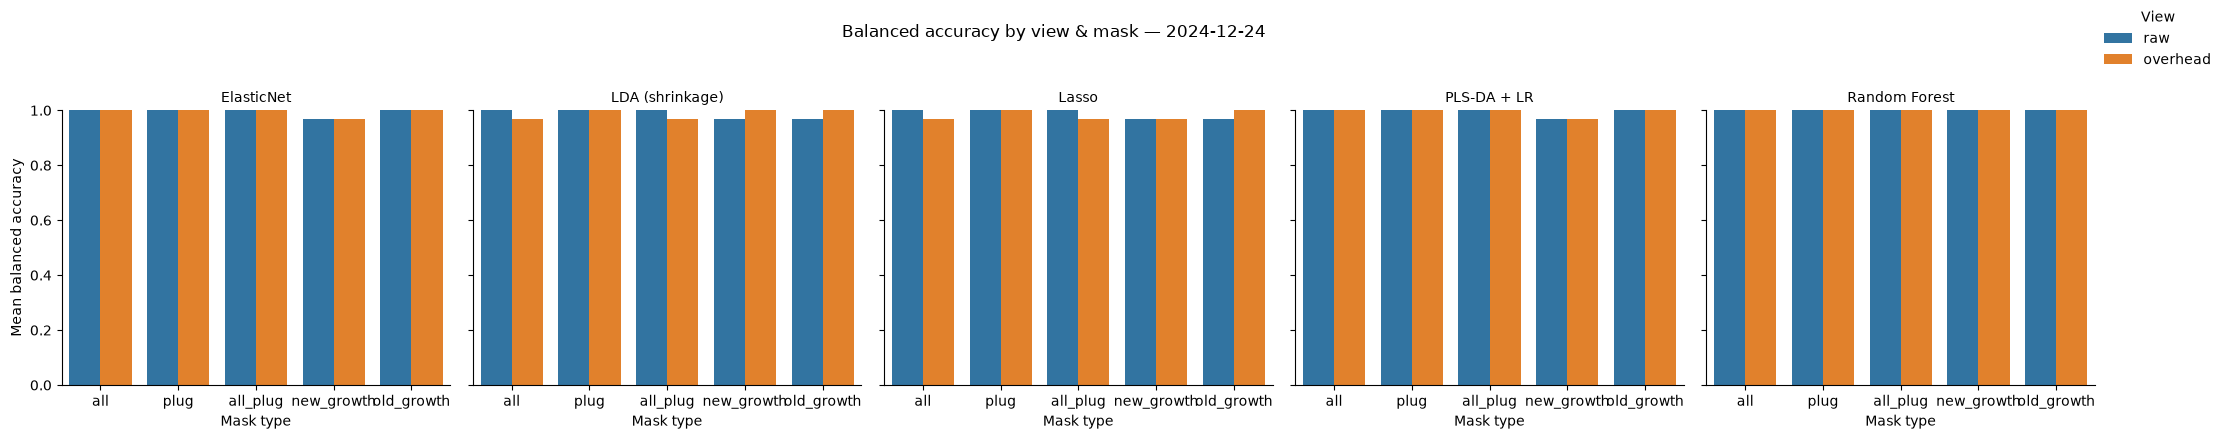

<Figure size 900x500 with 0 Axes>

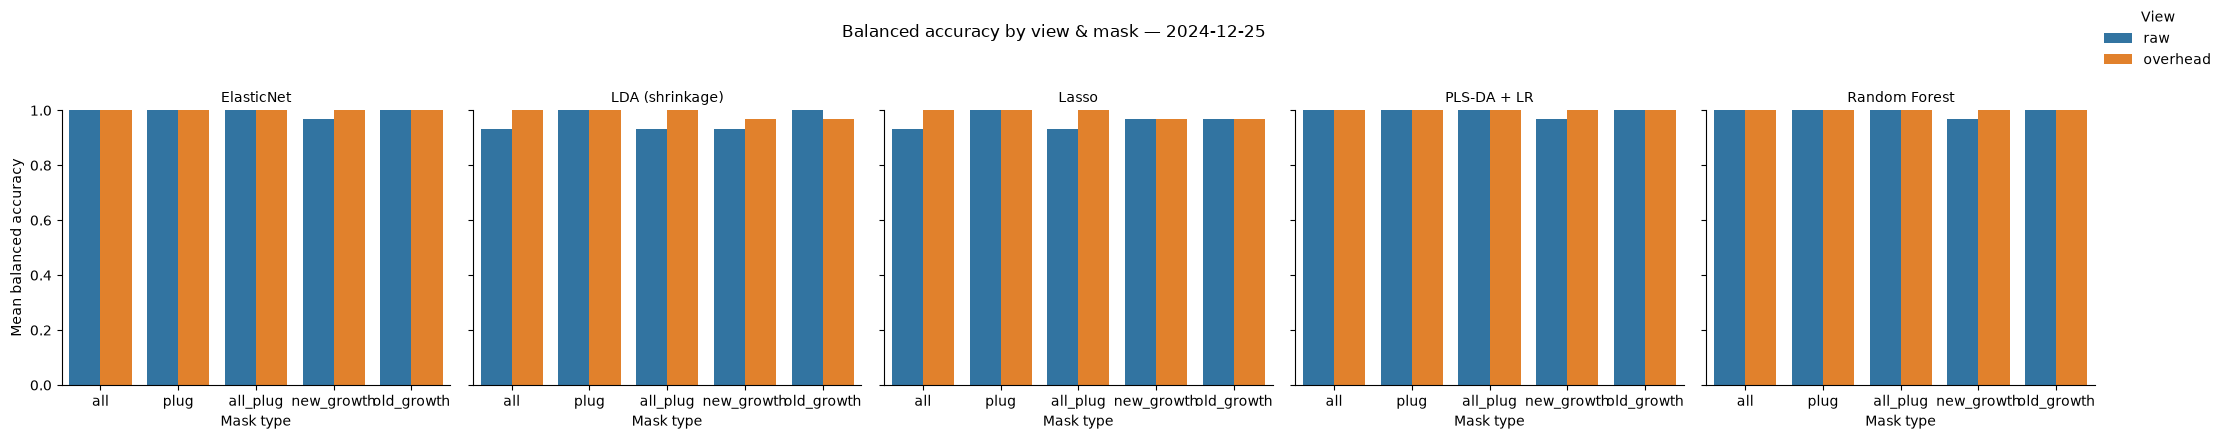

<Figure size 900x500 with 0 Axes>

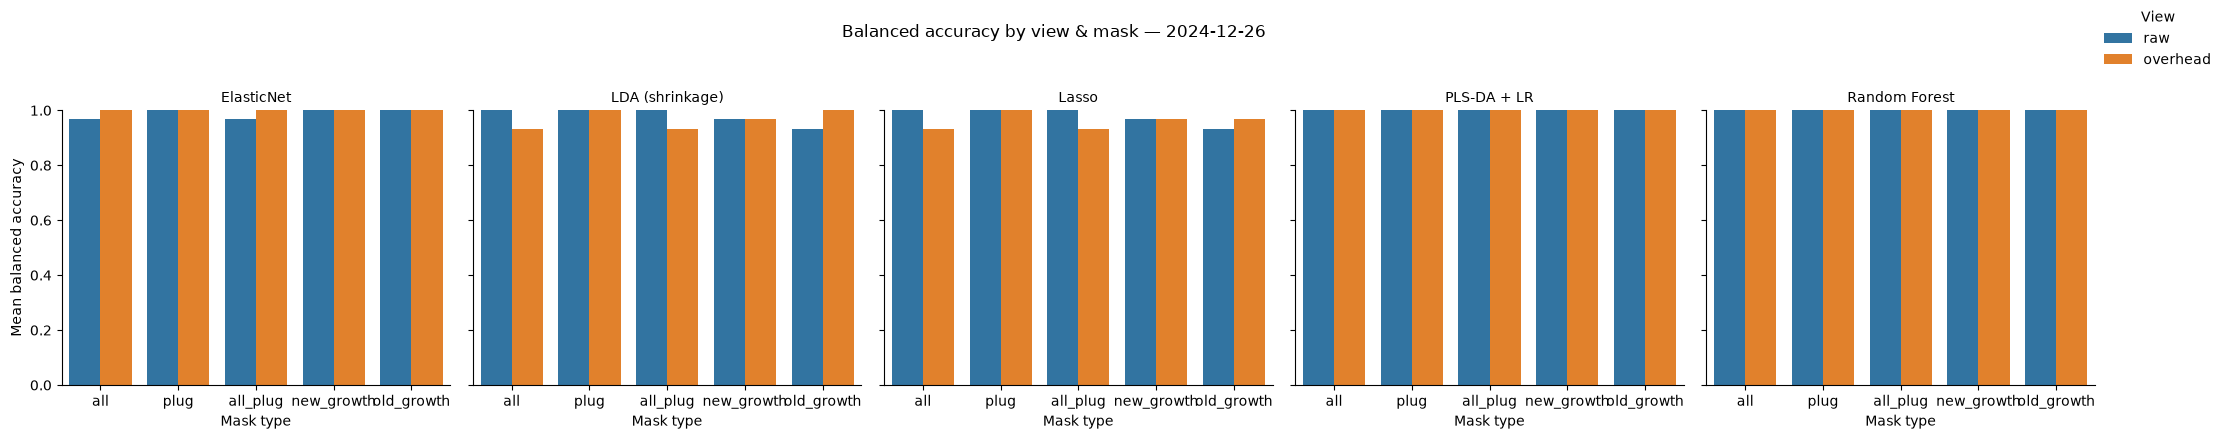

<Figure size 900x500 with 0 Axes>

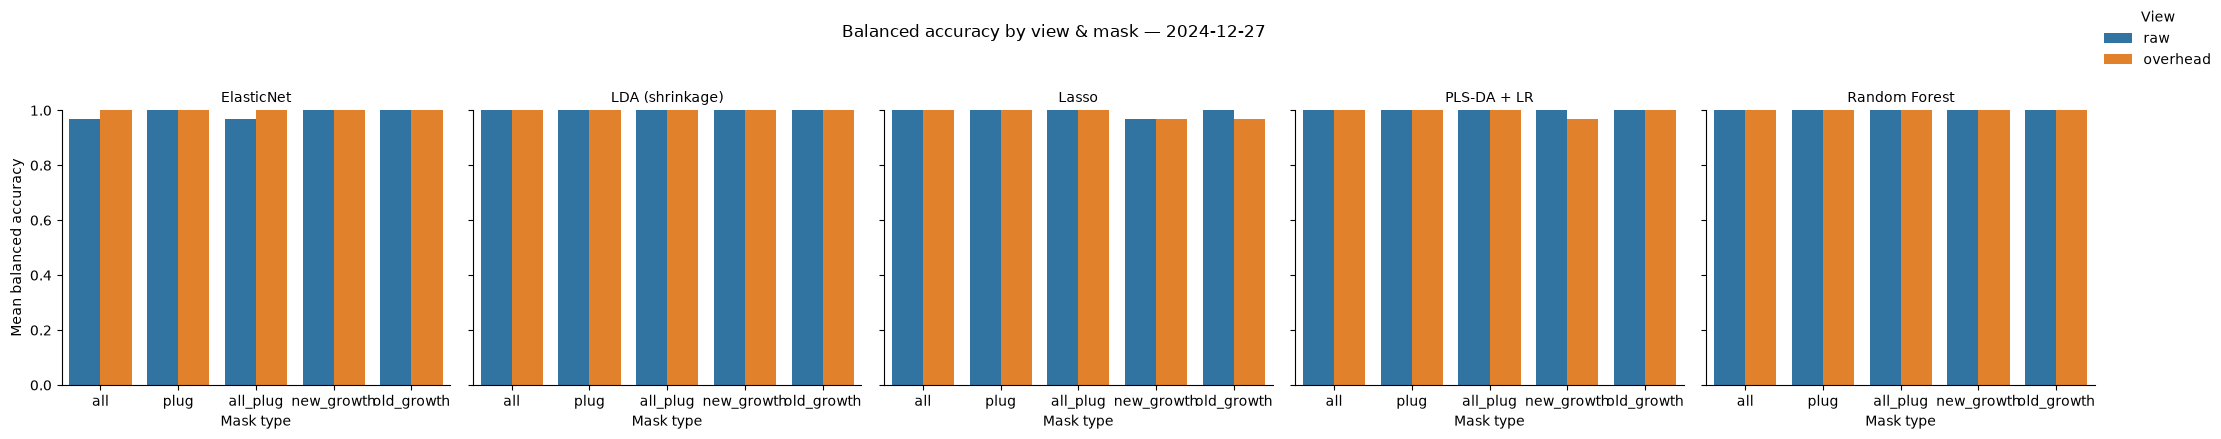

<Figure size 900x500 with 0 Axes>

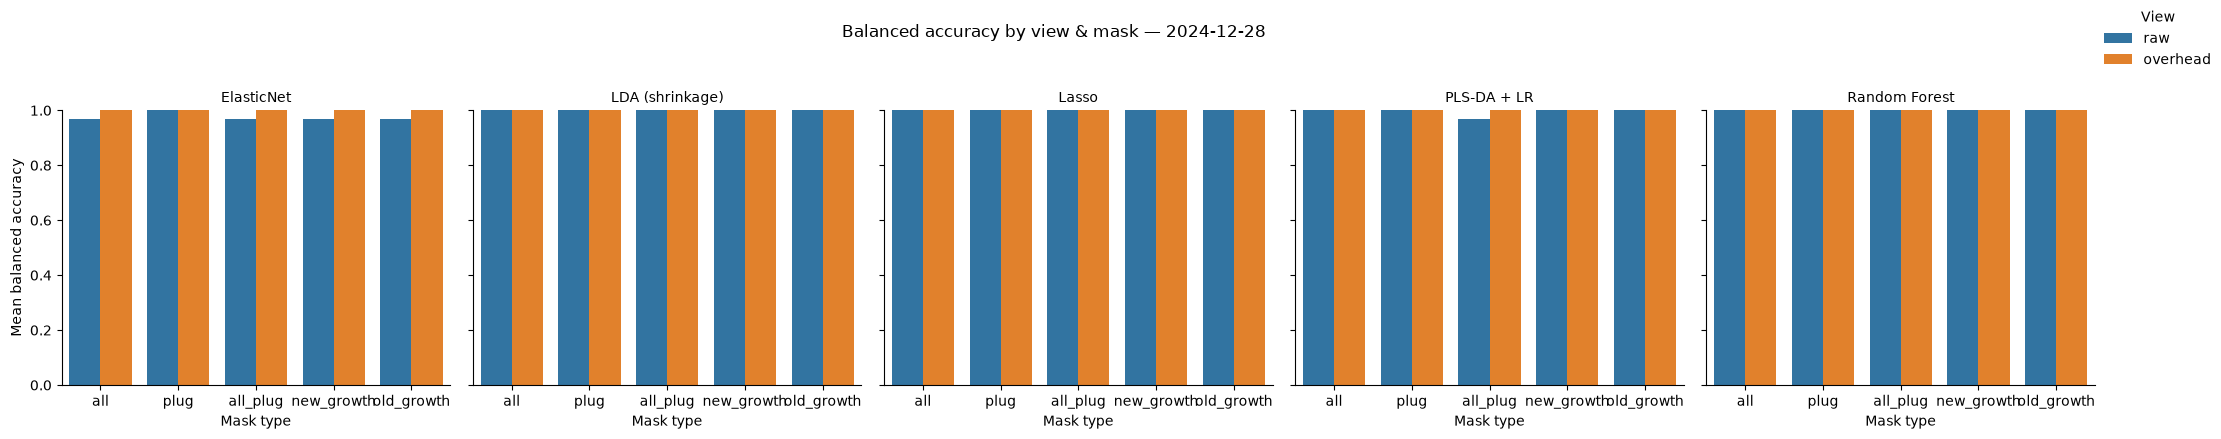

<Figure size 900x500 with 0 Axes>

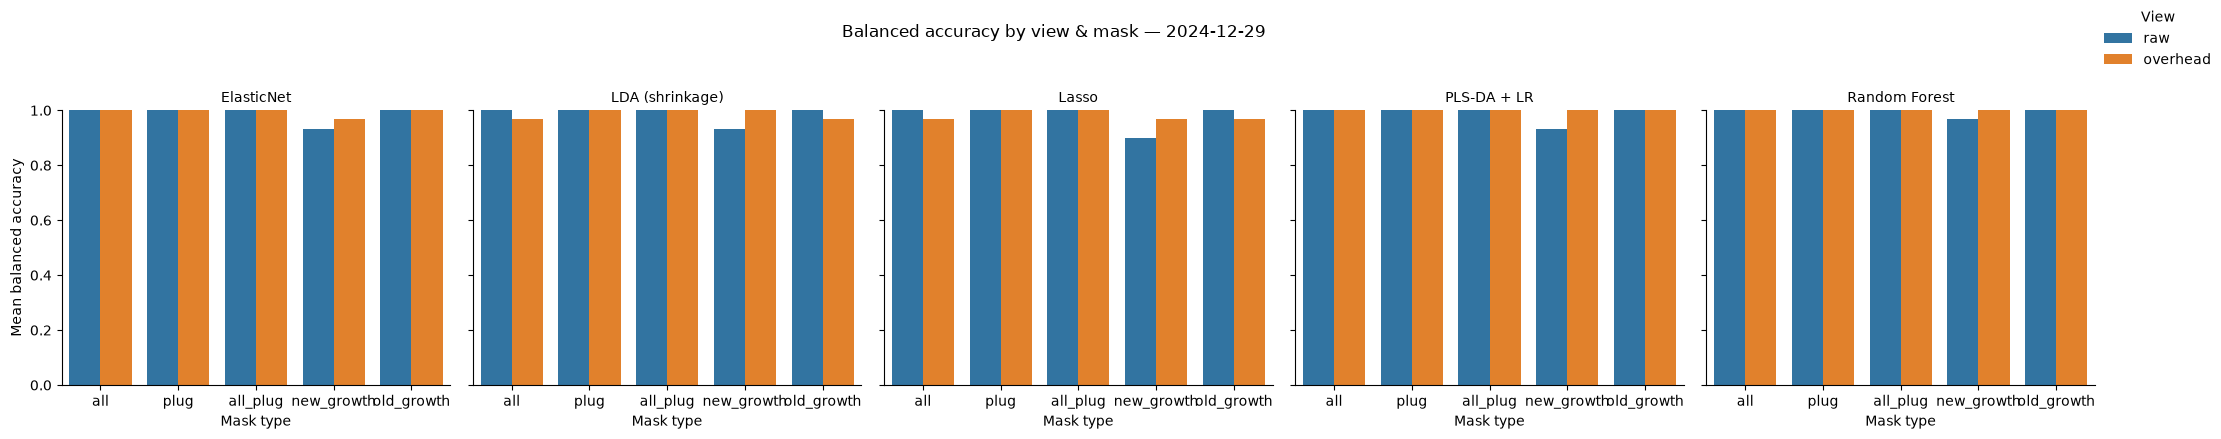

<Figure size 900x500 with 0 Axes>

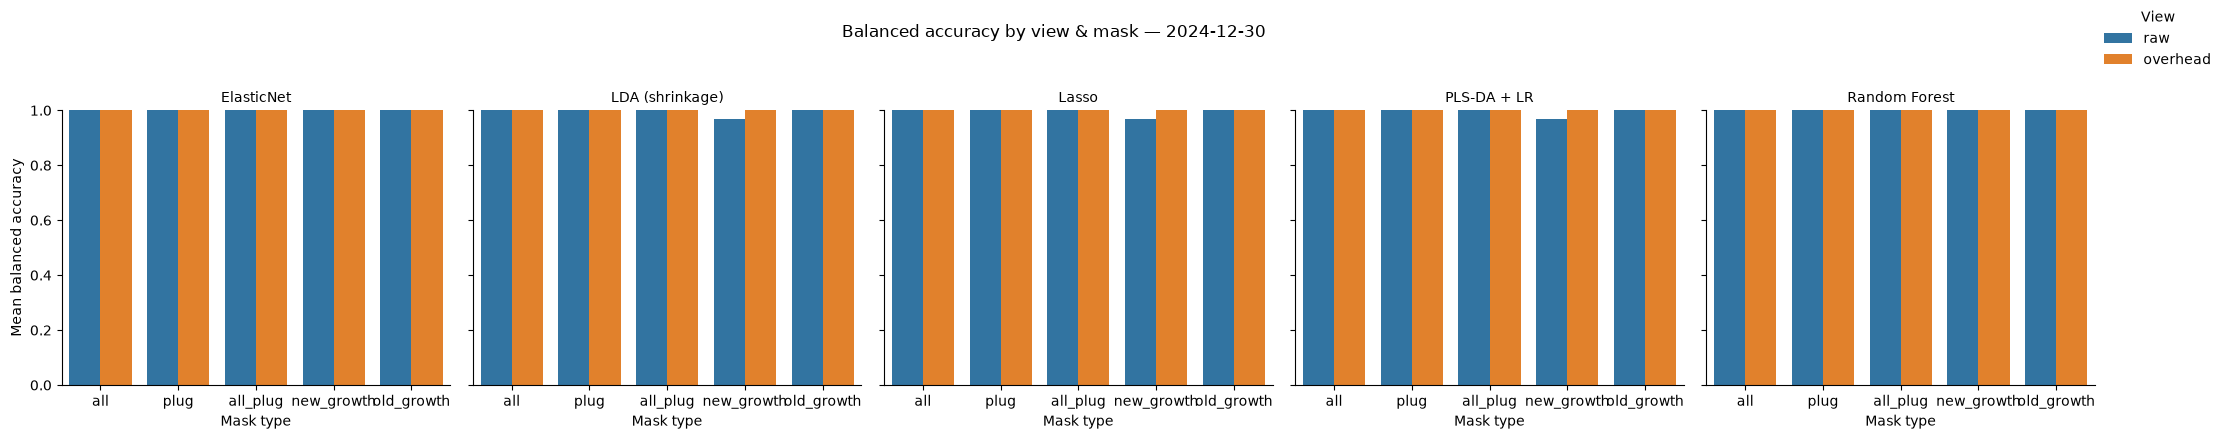

<Figure size 900x500 with 0 Axes>

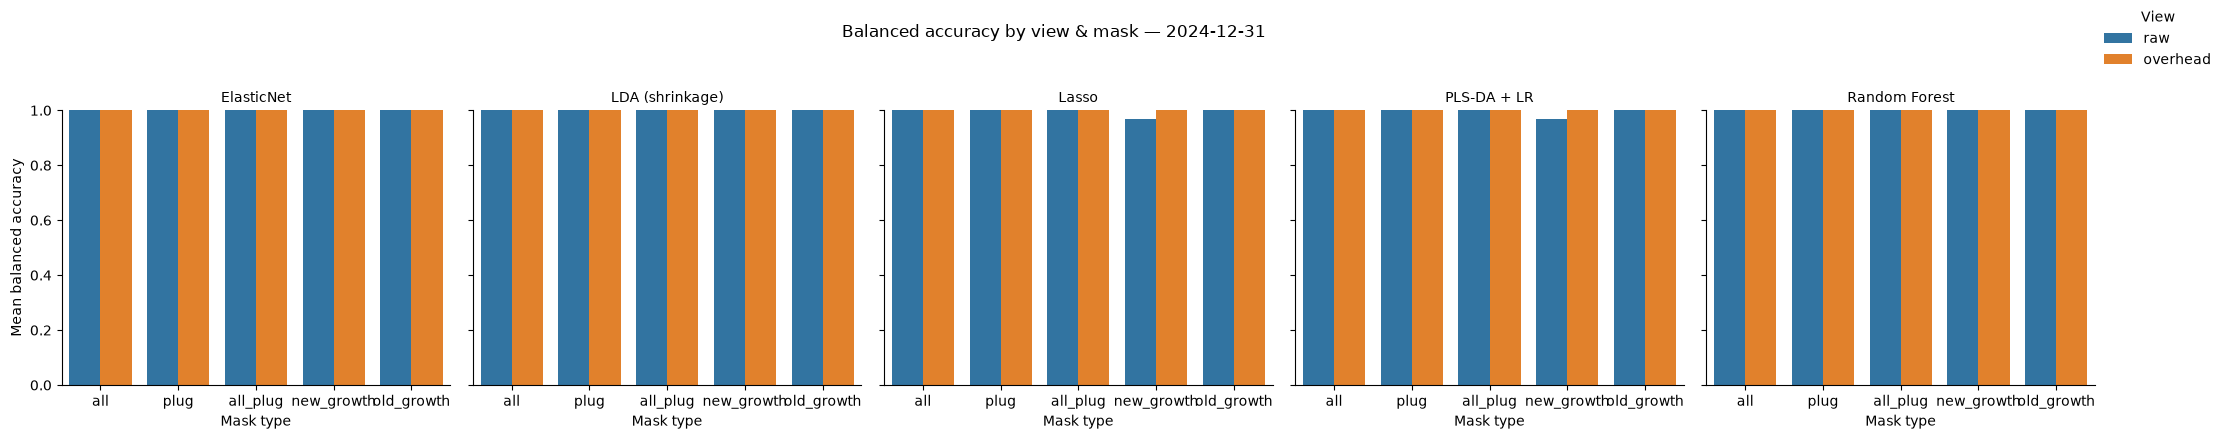

In [28]:
for date_to_plot in df_scores_fungus_class["date"].unique():
#date_to_plot = df_scores_fungus_class["date"].max()   # or pick a specific date

    df_d = df_scores_fungus_class[df_scores_fungus_class["date"] == date_to_plot]

    plt.figure(figsize=(9, 5))

    g = sns.catplot(
        data=df_d,
        kind="bar",
        x="mask_type",
        y="mean_balanced_accuracy",
        hue="view",
        col="model_label",
        col_wrap=5,   # adjust
        order=mask_order,
        hue_order=view_order,
        col_order=model_order,
        errorbar=None,
        height=4,
        aspect=1
    )

    g.set_axis_labels("Mask type", "Mean balanced accuracy")
    g.set_titles("{col_name}")
    g._legend.set_title("View")
    # Move legend outside the plot area
    g._legend.set_bbox_to_anchor((1.05, 1))
    g.fig.suptitle(f"Balanced accuracy by view & mask — {date_to_plot}", y=1.05)
    g.set(ylim=(0, 1))
    plt.tight_layout()
    plt.show()

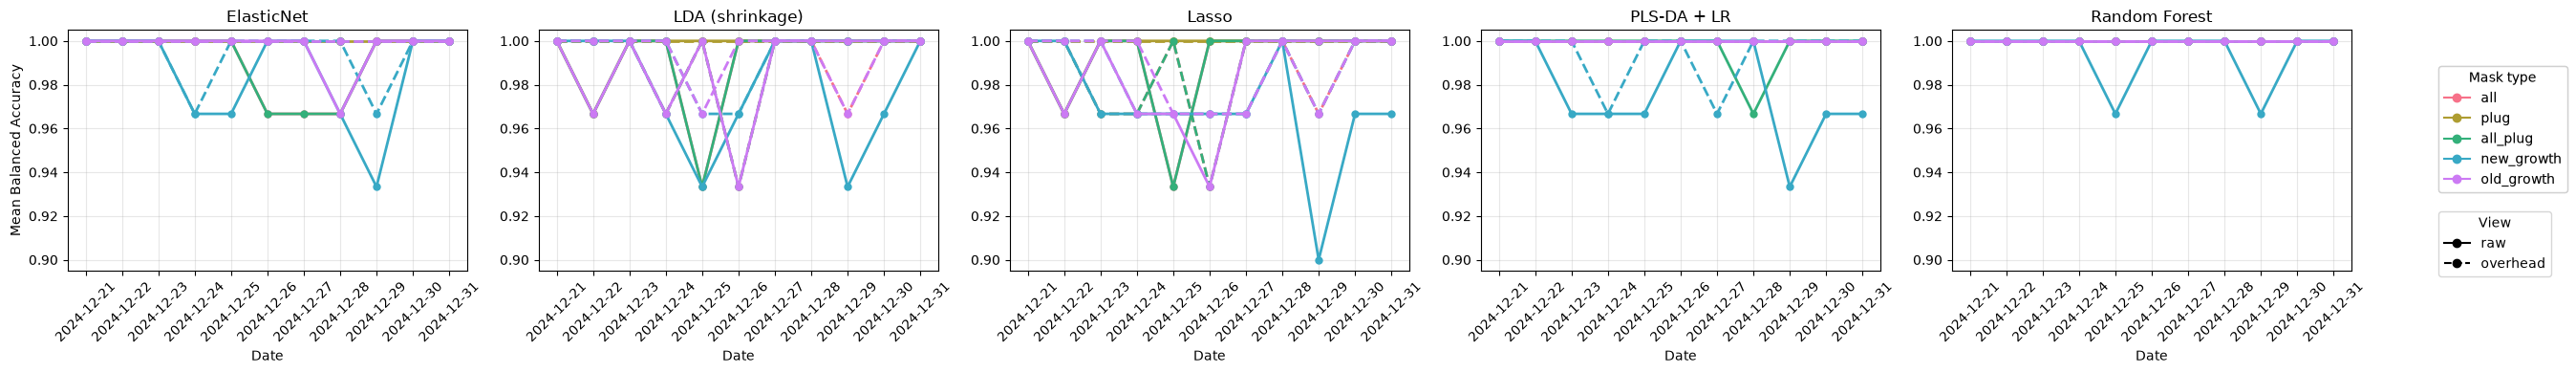

In [29]:
mask_order = ["all", "plug", "all_plug", "new_growth", "old_growth"]
mask_palette = dict(zip(mask_order, sns.color_palette("husl", len(mask_order))))

view_order = ["raw", "overhead"]
view_linestyles = {"raw": "-", "overhead": "--"}


metrics = df_scores_fungus_class.columns[df_scores_fungus_class.columns.str.startswith("mean_")] 

n_rows = len(metrics)
n_cols = len(model_order)

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(5*n_cols, 4*n_rows),
    sharex=True
)

if n_rows == 1:
    axes = [axes]
if n_cols == 1:
    axes = [[ax] for ax in axes]

for i, metric in enumerate(metrics):
    y_min = df_scores_fungus_class[metric].min()
    y_max = df_scores_fungus_class[metric].max()

    margin = (y_max - y_min) * 0.05
    y_min -= margin
    y_max += margin
    for j, model in enumerate(model_order):

        ax = axes[i][j]

        subset = df_scores_fungus_class[df_scores_fungus_class["model_label"] == model]
        for mask_type in mask_order:
            mask_subset = subset[subset["mask_type"] == mask_type]

            for view in view_order:
                view_subset = mask_subset[mask_subset["view"] == view]

                if not view_subset.empty:
                    view_subset = view_subset.sort_values("date")

                    ax.plot(
                        view_subset["date"],
                        view_subset[metric],
                        marker="o",
                        color=mask_palette[mask_type],
                        linestyle=view_linestyles[view],
                        linewidth=2,
                        markersize=5
                    )
        ax.set_ylim(y_min, y_max)
        if i == 0:
            ax.set_title(model)

        if j == 0:
            ax.set_ylabel(metric.replace("_", " ").title())
        else:
            ax.set_ylabel("")

        ax.set_xlabel("Date")
        ax.tick_params(axis='x', rotation=45)
        ax.grid(True, alpha=0.3)

mask_legend = [
    Line2D([0], [0],
           color=mask_palette[m],
           linestyle='-',
           marker='o',
           label=m)
    for m in mask_order
]

view_legend = [
    Line2D([0], [0],
           color='black',
           linestyle=view_linestyles[v],
           marker='o',
           label=v)
    for v in view_order
]

legend1 = fig.legend(
    handles=mask_legend,
    loc="center left",
    bbox_to_anchor=(1.02, 0.65),
    title="Mask type"
)

legend2 = fig.legend(
    handles=view_legend,
    loc="center left",
    bbox_to_anchor=(1.02, 0.35),
    title="View"
)

fig.add_artist(legend1)

plt.tight_layout()
plt.show()

### By color space

In [30]:
with open("../results/fungus_class/results_fungal_color_update.pkl", "rb") as f:
    results_fungus_class_color = pickle.load(f)

print(type(results_fungus_class_color))   # should be dict

<class 'dict'>


In [31]:
exp = results_fungus_class_color[('overhead', 'all', '2024-12-21')]

In [32]:
exp.get("RGB")[2]

,mean_accuracy,mean_balanced_accuracy
ElasticNet_MultinomialLR,1.0,1.0
Lasso_MultinomialLR,1.0,1.0
ShrinkageLDA,1.0,1.0
PLSDA_PLSScores_plus_LR,1.0,1.0
RandomForest,1.0,1.0


In [33]:
rows = []

for (view, mask_type, date), v in results_fungus_class_color.items():
    for color_space in v.keys():  
        s = v.get(color_space)[2]["mean_balanced_accuracy"]

        df_tmp = s.rename("mean_balanced_accuracy").reset_index()
        df_tmp.columns = ["model", "mean_balanced_accuracy"]

        df_tmp["view"] = view
        df_tmp["mask_type"] = mask_type
        df_tmp["date"] = date
        df_tmp["color_space"] = color_space

        rows.append(df_tmp)

df_scores_fungus_class_color = pd.concat(rows, ignore_index=True)


In [34]:

# optional: reorder columns
df_scores_fungus_class_color = df_scores_fungus_class_color[["view", "mask_type", "date","color_space", "model", "mean_balanced_accuracy"]]

In [35]:
model_label_map = {
    "ElasticNet_MultinomialLR": "ElasticNet",
    "Lasso_MultinomialLR": "Lasso",
    "ShrinkageLDA": "LDA (shrinkage)",
    "RandomForest": "Random Forest",
    "PLSDA_PLSScores_plus_LR": "PLS-DA + LR",
}

df_scores_fungus_class_color["model_label"] = (
    df_scores_fungus_class_color["model"]
    .map(model_label_map)
)

In [36]:

pivot = (
    df_scores_fungus_class_color
    .groupby(["model_label", "color_space"])["mean_balanced_accuracy"]
    .mean()
    .unstack("color_space")      # columns = color spaces
    .round(3)
)
pivot


color_space,Grey,HSV,LAB,Ncolor,RGB
model_label,,,,,
ElasticNet,0.982,0.992,0.998,0.847,0.989
LDA (shrinkage),0.976,0.988,0.999,0.818,0.995
Lasso,0.976,0.985,0.998,0.836,0.988
PLS-DA + LR,0.983,0.994,0.996,0.816,0.990
Random Forest,0.980,0.998,1.000,0.870,0.988


In [37]:
models = df_scores_fungus_class_color["model"].unique()
color_types = df_scores_fungus_class_color["color_space"].unique()

n_rows = len(models)
n_cols = len(color_types)


In [38]:
color_types

array(['RGB', 'HSV', 'LAB', 'Grey', 'Ncolor'], dtype=object)

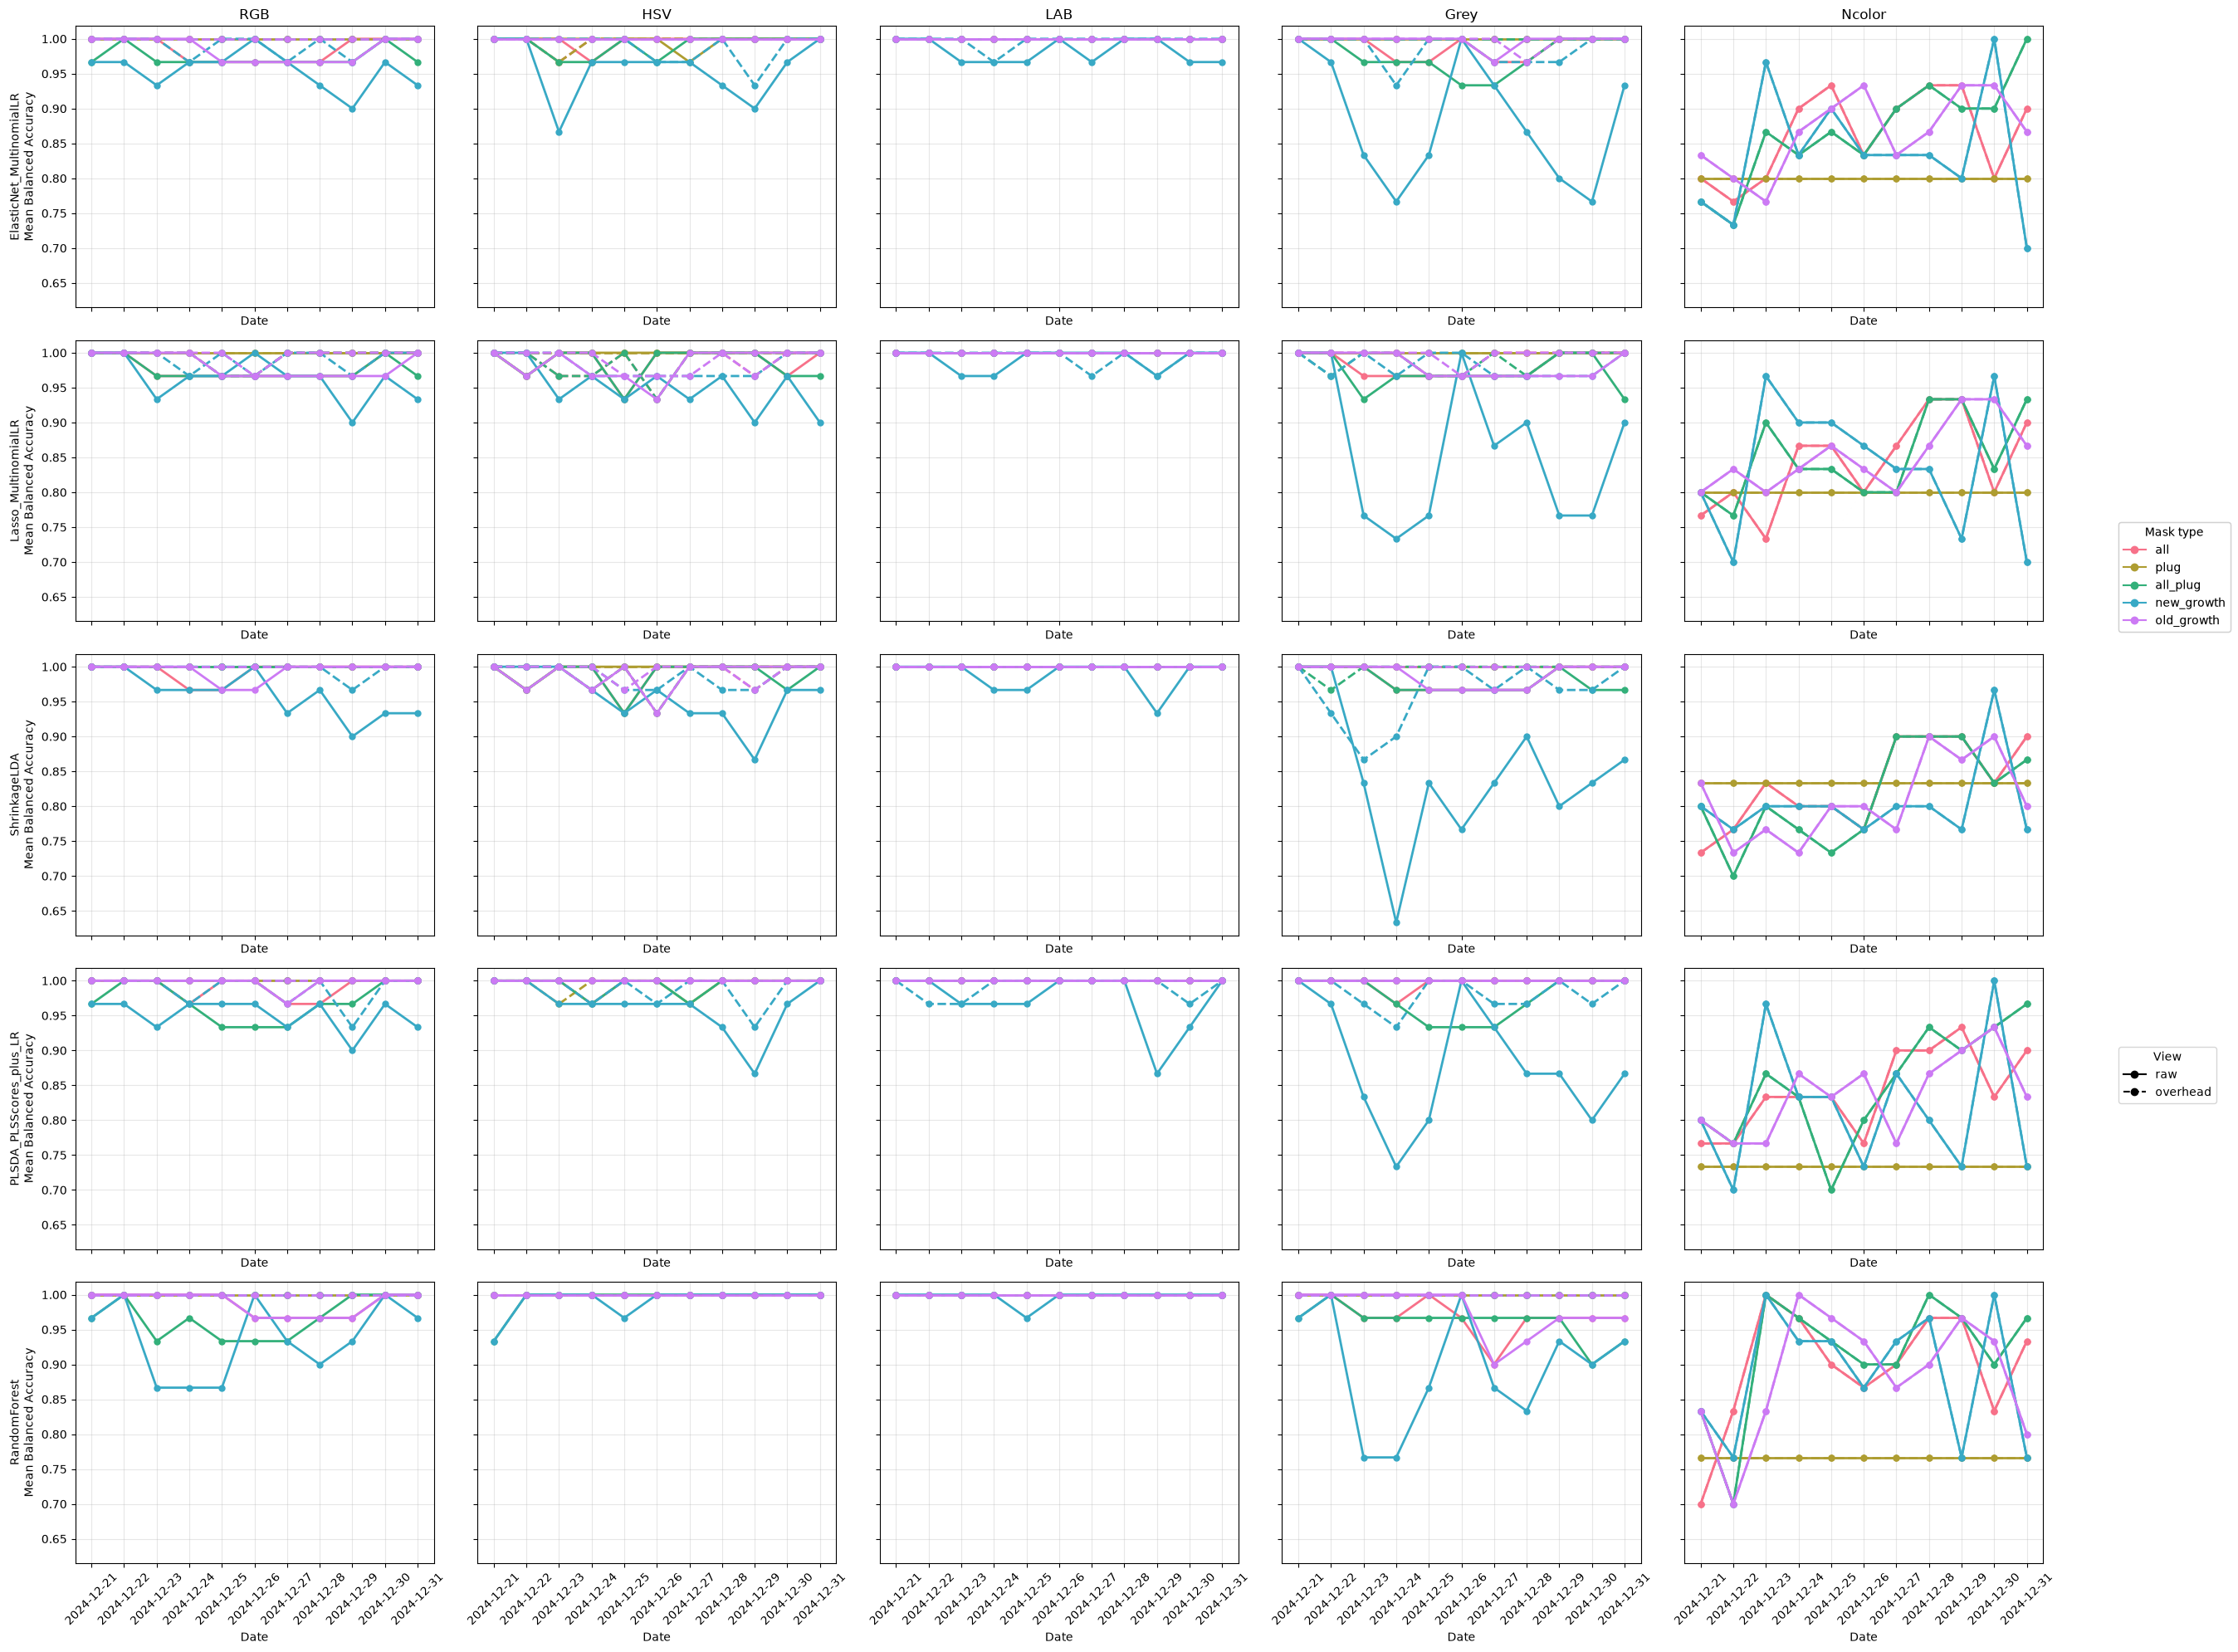

In [39]:
fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(5*n_cols, 4*n_rows),
    sharex=True,
    sharey=True
)

if n_rows == 1:
    axes = [axes]
if n_cols == 1:
    axes = [[ax] for ax in axes]

legend_handles = {}

for i, model in enumerate(models):
    for j, color_type in enumerate(color_types):

        ax = axes[i][j]

        subset = df_scores_fungus_class_color[
            (df_scores_fungus_class_color["model"] == model) &
            (df_scores_fungus_class_color["color_space"] == color_type)
        ]

        for mask_type in mask_order:
            mask_subset = subset[subset["mask_type"] == mask_type]

            for view in view_order:
                view_subset = mask_subset[mask_subset["view"] == view]

                if not view_subset.empty:
                    view_subset = view_subset.sort_values("date")

                    line, = ax.plot(
                        view_subset["date"],
                        view_subset["mean_balanced_accuracy"],
                        marker="o",
                        color=mask_palette[mask_type],
                        linestyle=view_linestyles[view],
                        linewidth=2,
                        markersize=5,
                        label=f"{view}-{mask_type}"
                    )

                    key = f"{view}-{mask_type}"
                    if key not in legend_handles:
                        legend_handles[key] = line

        # Column titles on top row
        if i == 0:
            ax.set_title(color_type)

        # Row labels on left column
        if j == 0:
            ax.set_ylabel(f"{model}\nMean Balanced Accuracy")
        else:
            ax.set_ylabel("")

        ax.set_xlabel("Date")
        ax.tick_params(axis='x', rotation=45)
        ax.grid(True, alpha=0.3)

# ---- Mask legend (color only) ----
mask_legend = [
    Line2D([0], [0],
           color=mask_palette[m],
           linestyle='-',
           marker='o',
           label=m)
    for m in mask_order
]

# ---- View legend (linestyle only) ----
view_legend = [
    Line2D([0], [0],
           color='black',
           linestyle=view_linestyles[v],
           marker='o',
           label=v)
    for v in view_order
]

legend1 = fig.legend(
    handles=mask_legend,
    loc="center left",
    bbox_to_anchor=(1.02, 0.65),
    title="Mask type"
)

legend2 = fig.legend(
    handles=view_legend,
    loc="center left",
    bbox_to_anchor=(1.02, 0.35),
    title="View"
)

fig.add_artist(legend1)

plt.tight_layout()
plt.show()